In [1]:
# for linux
# %sudo apt-get install poppler-utils tesseract-ocr libmagic-dev

# for mac
# %brew install poppler tesseract libmagic

In [2]:
%pip install -Uq "unstructured[all-docs]" pillow lxml pillow
%pip install -Uq chromadb tiktoken
%pip install -Uq langchain langchain-community langchain-openai langchain-groq
%pip install -Uq python_dotenv

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chromadb 0.5.23 requires tokenizers<=0.20.3,>=0.13.2, but you have tokenizers 0.21.0 which is incompatible.
You should consider upgrading via the '/Users/rashmir/Desktop/all learnings/venv-multimodal/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.47.1 requires tokenizers<0.22,>=0.21, but you have tokenizers 0.20.3 which is incompatible.
You should consider upgrading via the '/Users/rashmir/Desktop/all learnings/venv-multimodal/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [48]:
# extract data
from unstructured.partition.pdf import partition_pdf

output_path = "./content/"
file_path = output_path + "attention.pdf"

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True, # extract tables
    strategy="hi_res",    #mandatory to infer tables

    extract_image_block_types=["Image"],  # to extract images
    # image_output_dir_path=output_path + "images/",  # to save images

    extract_image_block_to_payload=True,      # extract base64 for API usage

    chunking_strategy="by_title",
    max_characters=10000,
    combine_text_under_n_chars=2000,
    new_after_n_chars=6000,
)


In [49]:
set([str(type(el)) for el in chunks])
# print("\n")
# len(chunks)

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [50]:
chunks[0].to_dict()

{'type': 'CompositeElement',
 'element_id': 'a43b32eb5c561ab9688edebf84b17900',
 'text': '3\n\n2023\n\n2\n\n0\n\n2\n\ng u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0\n\n7\n\n1\n\n:\n\nv\n\narXiv\n\ni\n\nX\n\nr\n\na\n\nProvided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\n\nAttention Is All You Need\n\nAshish Vaswani∗\n\nGoogle Brain\n\navaswani@google.com\n\nNoam Shazeer∗ Google Brain noam@google.com\n\nNiki Parmar∗ Google Research nikip@google.com\n\nJakob Uszkoreit∗\n\nGoogle Research usz@google.com\n\nLlion Jones∗\n\nGoogle Research llion@google.com\n\nAidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu\n\nŁukasz Kaiser∗ Google Brain lukaszkaiser@google.com\n\nIllia Polosukhin∗ ‡\n\nillia.polosukhin@gmail.com\n\nAbstract\n\nThe dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a dec

In [51]:
chunks[3].metadata.orig_elements

In [18]:
# this is what an extracted image looks like

elements = chunks[3].metadata.orig_elements
chunk_images = [el for el in elements if "Image" in str(type(el))]

chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': 'ff6f9d02-a729-423a-84cb-3d27d566b16a',
 'text': 'Scaled Dot-Product Attention  Multi-Head Attention ',
 'metadata': {'detection_class_prob': 0.8599751591682434,
  'coordinates': {'points': ((410.50833333333327, 197.0675599999999),
    (410.50833333333327, 669.3112182617188),
    (1311.755126953125, 669.3112182617188),
    (1311.755126953125, 197.0675599999999)),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2024-12-28T19:20:52',
  'filetype': 'PPM',
  'languages': ['eng'],
  'page_number': 4,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

# Separate extracted elements into tables, text and images

In [19]:
# separate tables and texts

tables=[]
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)
    
    if "CompositeElement" in str(type(chunk)):
        texts.append(chunk)

In [22]:
#Get the images from Composite Element Objects
def get_images_base64(chunks):
    images_b64 =[]
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)


['...']

### Check what the image looks like

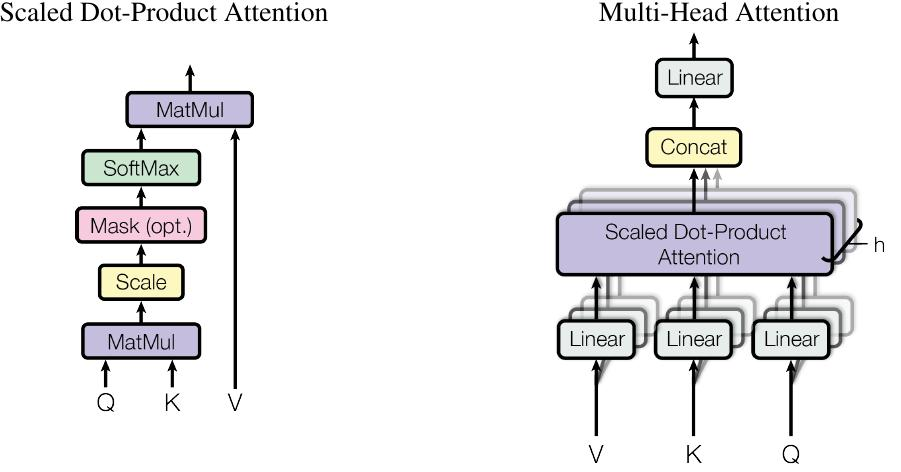

In [33]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # display the image
    display(Image(data=image_data))

display_base64_image(images[1])

# Summarizing the Data

In [34]:
%pip install -Uq langchain-groq

You should consider upgrading via the '/Users/rashmir/Desktop/all learnings/venv-multimodal/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [35]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [36]:
# Prompt 
prompt_text="""
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}
"""

prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary Chain
model = ChatGroq(temperature=0.5,model="llama-3.1-8b-instant")
summarize_chain = prompt | model | StrOutputParser()


In [53]:
# summarize text
text_summaries = summarize_chain.batch(texts,{"max_concurrency":3})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html,{"max_concurrency":3})

In [54]:
text_summaries

['Google proposes a new Transformer network architecture based solely on attention mechanisms, replacing recurrence and convolutions, achieving better results in machine translation tasks and requiring less training time.',
 'Recurrent neural networks are established as state of the art in sequence modeling but have limitations due to sequential computation. Attention mechanisms have improved sequence modeling but are often used with recurrent networks. This work proposes the Transformer, a model that uses only attention mechanisms to draw global dependencies, allowing for more parallelization and reaching a new state of the art in translation quality.',
 'The Transformer model architecture consists of an encoder and decoder with stacked self-attention and feed-forward layers, employing residual connections and layer normalization. The encoder has 6 layers with 2 sub-layers each, and the decoder has 6 layers with 3 sub-layers each, including a multi-head attention sub-layer over the en

### image summaries

In [55]:
%pip install -Uq langchain_openai

You should consider upgrading via the '/Users/rashmir/Desktop/all learnings/venv-multimodal/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [56]:
from langchain_openai import ChatOpenAI

prompt_template = """ Describe the image in detail. For context,
                  the image is part of a research paper explaining the transformers
                  architecture. Be specific about graphs, such as bar plots."""

messages = [
    (
        "user",
        [
            {"type":"text","text":prompt_template},
            {"type":"image_url", "image_url":"data:image/jped;base64,{image}"},
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | ChatOpenAI(model="gpt-4o-mini") | StrOutputParser()

image_summaries = chain.batch(images)


In [58]:
image_summaries

['The image depicts a flowchart illustrating the architecture of Transformers, a model used in natural language processing and other tasks. Here’s a detailed description:\n\n1. **Overall Structure**: \n   - The diagram is divided into two main sections: the **Encoder** (on the left) and the **Decoder** (on the right). Each section is visually separated, with arrows indicating the flow of information.\n\n2. **Encoder Section**:\n   - At the top, there is an **Input Embedding** labeled in pink. Below that, a **Positional Encoding** component is connected to the Input Embedding, indicating that positional information is added to the input tokens.\n   - The Encoder consists of multiple layers (denoted as **Nx**), each containing:\n     - A **Multi-Head Attention** block, followed by an **Add & Norm** layer.\n     - A **Feed Forward** layer, also followed by an **Add & Norm** layer.\n   - These components are stacked vertically, with arrows illustrating the flow from the Input Embedding thr

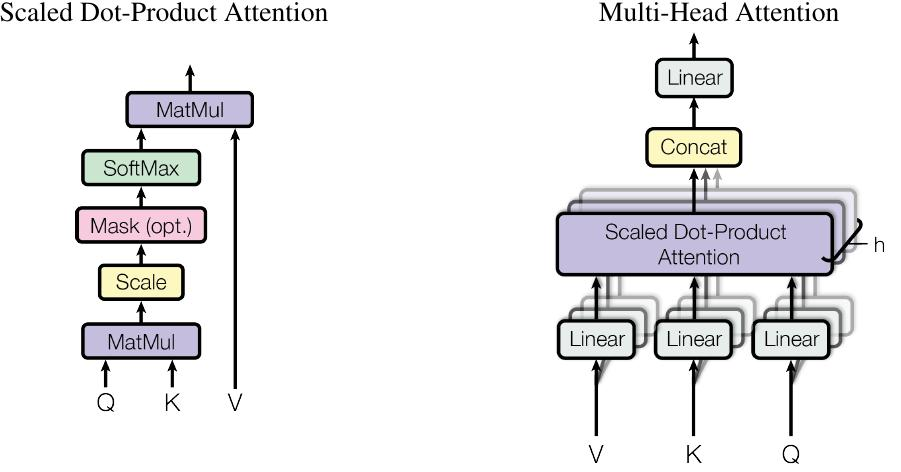

In [62]:
display_base64_image(images[1])

In [61]:
print(image_summaries[1])

The image consists of two diagrams illustrating components of the transformer architecture: "Scaled Dot-Product Attention" on the left and "Multi-Head Attention" on the right.

### Left Diagram: Scaled Dot-Product Attention
- **Title**: "Scaled Dot-Product Attention"
- **Components**:
  - **MatMul (Matrix Multiplication)**: Represented in a purple box at the top. This operation likely computes the dot product of query (Q) and key (K) matrices.
  - **SoftMax**: A green box below MatMul, which normalizes the dot product scores into probabilities.
  - **Mask (optional)**: A pink box indicating an optional masking step, usually employed to prevent attending to certain positions in the input sequence.
  - **Scale**: A yellow box that suggests a scaling operation, typically applied to the dot product scores.
  - **MatMul**: Another purple box at the bottom, indicating a final matrix multiplication, likely with the value (V) matrix.

- **Arrows**: Indicate the flow of data through these opera

# Load data and summaries to vectorstore

In [64]:
%pip install -Uq langchain_chroma

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.47.1 requires tokenizers<0.22,>=0.21, but you have tokenizers 0.20.3 which is incompatible.
You should consider upgrading via the '/Users/rashmir/Desktop/all learnings/venv-multimodal/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [67]:
import uuid
from langchain_chroma import Chroma
from langchain.storage import InMemoryStore
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain.retrievers.multi_vector import MultiVectorRetriever

# the vector store to index the child chunks
vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"))

# the storage layer for parent documents
store = InMemoryStore()
id_key = "doc_id"

#the retriever
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

print(store)
print(vectorstore)

In [ ]:
# add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key:doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids,texts)))

# add tables
# table_ids = [str(uuid.uuid4()) for _ in tables]
# summary_tables = [
#     Document(page_content=summary, metadata={id_key:table_ids[i]}) for i, summary in enumerate(table_summaries)
# ]
# retriever.vectorstore.add_documents(summary_tables)
# retriever.docstore.mset(list(zip(table_ids,tables)))

# add images
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key:img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids,images)))

In [70]:
#Retrieve

chunks = retriever.invoke(
    "what is multi-head attention?",
)

In [72]:
chunks

 '...',

In [74]:
# since we are using chunking, we get chunks of related documents
# since we selected "by_title" as the chunking strategy, we get sections of the document based on their title

for i, chunk in enumerate(chunks):
    if "CompositeElement" in str(type(chunk)):
        print("\n\n Chunk:",i)
        for doc in chunk.metadata.orig_elements:
            print(doc.to_dict()["type"], doc.metadata.page_number)



 Chunk: 0
Title 4
NarrativeText 4
NarrativeText 4
UncategorizedText 4
NarrativeText 5
NarrativeText 5
Formula 5
NarrativeText 5
NarrativeText 5
Title 5
NarrativeText 5
ListItem 5
ListItem 5
ListItem 5


 Chunk: 1
Title 4
NarrativeText 4
NarrativeText 4
UncategorizedText 4
NarrativeText 5
NarrativeText 5
Formula 5
NarrativeText 5
NarrativeText 5
Title 5
NarrativeText 5
ListItem 5
ListItem 5
ListItem 5


 Chunk: 3
Title 10
NarrativeText 10
NarrativeText 10
NarrativeText 10
NarrativeText 10
NarrativeText 10
Title 10
ListItem 10
ListItem 10
ListItem 10
ListItem 10
Footer 10
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
ListItem 11
Footer 11
ListItem 12
ListItem 12
ListItem 12
ListItem 12
ListItem 12
ListItem 12
ListItem 12
ListItem 12
ListItem 12
ListItem 12
ListItem 12


In [79]:
chunks[1].metadata.orig_elements[0].to_dict()

{'type': 'Title',
 'element_id': '3ef23a9b-7a32-4722-b07e-a95e5cf58a98',
 'text': '3.2.2 Multi-Head Attention',
 'metadata': {'detection_class_prob': 0.9022545218467712,
  'coordinates': {'points': ((297.4408264160156, 1751.5182872222222),
    (297.4408264160156, 1779.192176111111),
    (643.9487915039062, 1779.192176111111),
    (643.9487915039062, 1751.5182872222222)),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2024-12-28T19:20:52',
  'filetype': 'PPM',
  'languages': ['eng'],
  'page_number': 4}}

In [83]:
from langchain_core.documents import Document

def extract_page_numbers_from_chunk(chunk):
    elements = chunk.metadata.orig_elements

    page_numbers=set()
    for element in elements:
        page_numbers.add(element.metadata.page_number)

    return page_numbers

def render_page(docs, page_number, highlight=False):
    """Renders the content of a specific page."""
    print(f"\nDisplaying content for Page {page_number}:")
    for doc in docs:
        if doc.metadata.get("page_number") == page_number:
            category = doc.metadata.get("category", "Unknown")
            content = doc.page_content
            print(f"\n[{category}]\n{content}")
            if highlight:
                print("Highlighted Content")

def display_chunk_pages(chunk):
    page_numbers = extract_page_numbers_from_chunk(chunk)
    # print("Pages:",page_numbers)
    docs = []
    for element in chunk.metadata.orig_elements:
        metadata = element.metadata.to_dict()
        if "Table" in str(type(element)):
            metadata["category"] = "Table"
        elif "Image" in str(type(element)):
            metadata["category"] = "Image"
        else:
            metadata["category"] = "Text"

        metadata["page_number"] = int(element.metadata.page_number)

        docs.append(Document(page_content=element.text, metadata=metadata))

    for page_number in page_numbers:
        render_page(docs, page_number, False)

extract_page_numbers_from_chunk(chunks[1])
display_chunk_pages(chunks[1])


Displaying content for Page 4:

[Text]
3.2.2 Multi-Head Attention

[Text]
Instead of performing a single attention function with dmodel-dimensional keys, values and queries, we found it beneficial to linearly project the queries, keys and values h times with different, learned linear projections to dk, dk and dv dimensions, respectively. On each of these projected versions of queries, keys and values we then perform the attention function in parallel, yielding dv-dimensional

[Text]
‘To illustrate why the dot products get large, assume that the components of q and k are independent random variables with mean 0 and variance 1. Then their dot product, g -k = ves, qiki, has mean 0 and variance dx.

[Text]
4

Displaying content for Page 5:

[Text]
output values. These are concatenated and once again projected, resulting in the final values, as depicted in Figure 2.

[Text]
Multi-head attention allows the model to jointly attend to information from different representation subspaces at dif

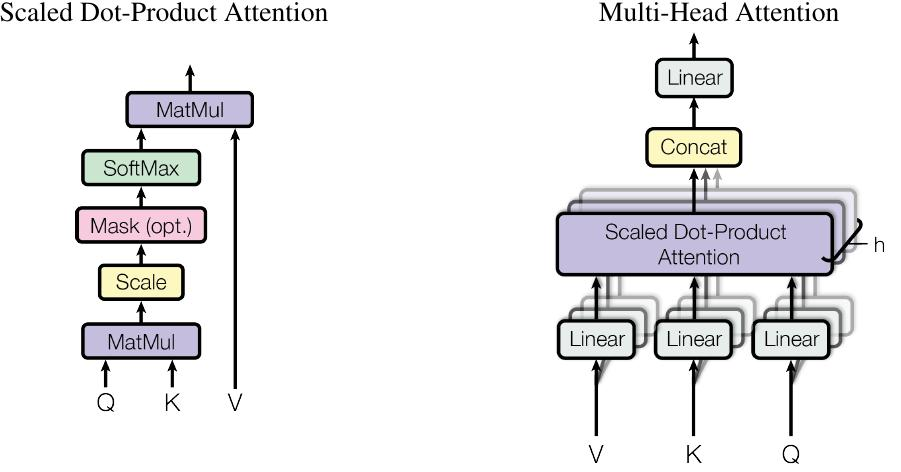

In [84]:
display_base64_image(chunks[2])

# RAG PIPELINE

In [90]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from base64 import b64decode

def parse_docs(docs):
    """Split the base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images":b64, "texts":text}

def build_prompt(kwargs):
    docs_by_type = kwargs["context"]
    user_question= kwargs["question"]

    context_text =""
    if len(docs_by_type["texts"])>0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables and the belwo image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type":"text", "text":prompt_template}]

    if len(docs_by_type["images"])>0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type":"image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"}
                }
            )
    
    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )



# create a chain
chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough()
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

# chain with sources
chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model="gpt-4o-mini")
        | StrOutputParser()
    )
)


In [91]:
response = chain.invoke(
    "What do the authors mean by 'attention'?"
)

print(response)

The authors describe 'attention' as a mechanism that maps a query and a set of key-value pairs to an output. This output is computed as a weighted sum of the values, where the weights are derived from a compatibility function that evaluates the relationship between the query and the corresponding keys. In the context provided, attention enables the model to focus on different parts of the input sequence when generating an output, allowing it to dynamically highlight relevant information based on the context of the query. This is implemented through functions like Scaled Dot-Product Attention and Multi-Head Attention, which enhance the model's ability to process information effectively across various representation subspaces.


Response: Multi-head attention is an extension of the attention mechanism that allows the model to focus on different parts of the input sequence simultaneously. Instead of using a single attention function, multi-head attention employs multiple attention heads, each with its own learned linear projections for the queries, keys, and values. 

This process involves the following steps:

1. **Linear Projections**: The queries (Q), keys (K), and values (V) are linearly projected multiple times (h times) into lower-dimensional spaces (dk and dv).
2. **Parallel Attention**: Each set of projected queries, keys, and values is processed in parallel through the attention mechanism, allowing the model to capture various aspects of relationships in the data.
3. **Concatenation**: The outputs from all attention heads are concatenated.
4. **Final Projection**: The concatenated outputs are then projected back to the original dimensionality to produce the final output.

This allows the model to atten

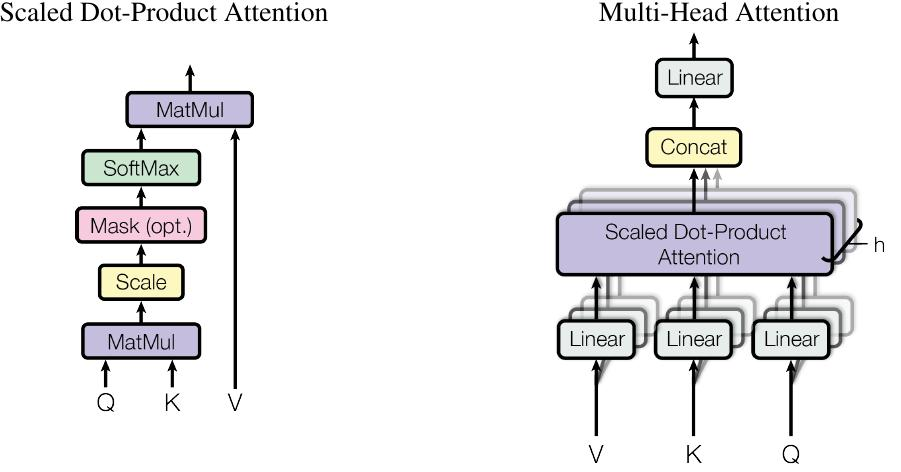

In [95]:
response = chain_with_sources.invoke(
    "What is multi-head attention?"
)

print("Response:", response["response"])

print("\n\nContext:\n")
for text in response["context"]["texts"]:
    print(text.text)
    print("Page number:", text.metadata.page_number)
    print("\n"+ "-"*50 + "\n")
for image in response["context"]["images"]:
    display_base64_image(image)